<a href="https://colab.research.google.com/github/ChronosXV/Aprendizaje-Automatico/blob/main/EDA_Consumo_Digital_Adolescentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consumo Digital en Adolescentes
## Análisis Exploratorio de Datos y preparación para Aprendizaje No Supervisado

**Materia:** Aprendizaje Automático  
**Objetivo del notebook:** realizar un EDA completo, documentar las decisiones de limpieza y preprocesamiento, construir un dataset limpio y preparar las variables para un problema de **clustering**.

### Pregunta de investigación

> **¿Es posible identificar perfiles diferenciados de adolescentes según sus patrones de uso de pantallas mediante técnicas de aprendizaje automático no supervisado y caracterizar dichos perfiles a partir de sus hábitos y características?**

### Enfoque general

El dataset contiene información sobre adolescentes, características demográficas, uso de pantallas, uso de dispositivos, sueño, somnolencia y rendimiento académico. El objetivo no es predecir una etiqueta conocida, sino descubrir grupos naturales de adolescentes con patrones de comportamiento digital semejantes.

Se distinguirán dos tipos de variables:

- **Variables de clusterización:** intervienen directamente en la formación de los grupos.
- **Variables de caracterización:** se utilizan después para comprender e interpretar los grupos encontrados.

El análisis es **exploratorio y descriptivo**. Las asociaciones observadas no deben interpretarse como relaciones causales.

# 1. Introducción

El uso de dispositivos electrónicos, redes sociales, videojuegos y servicios de televisión o streaming forma parte de la vida cotidiana de los adolescentes. Sin embargo, el comportamiento digital no es homogéneo: dos adolescentes pueden acumular una cantidad similar de horas de exposición a pantallas y, aun así, distribuir ese tiempo de manera muy diferente entre redes sociales, videojuegos, juegos en dispositivos móviles, contenido audiovisual u otras actividades.

Por esta razón, observar únicamente el **tiempo total de pantalla** puede ocultar patrones relevantes. El propósito de este trabajo es utilizar técnicas de **Aprendizaje Automático No Supervisado** para identificar perfiles naturales de comportamiento digital.

Los grupos serán formados principalmente a partir de variables relacionadas con el uso de pantallas. Luego se utilizarán variables demográficas, de sueño, somnolencia y rendimiento académico para caracterizar esos perfiles.

### Beneficios esperados

La segmentación puede ayudar a:

- comprender la heterogeneidad de los patrones de consumo digital;
- identificar perfiles predominantes dentro de la población adolescente;
- describir diferencias entre grupos;
- orientar investigaciones posteriores;
- aportar evidencia para estrategias diferenciadas de educación, prevención, concientización o comunicación.

El objetivo no es demostrar causalidad entre uso de pantallas, sueño o desempeño académico, sino descubrir perfiles y explorar asociaciones.

# 2 Librerías y configuración

In [1]:
# Ejecutamos el comando git clone y descargamos nuestro
!git clone https://{git_token}@github.com/ChronosXV/Aprendizaje-Automatico.git

Cloning into 'Aprendizaje-Automatico'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 52 (delta 12), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 16.33 MiB | 33.86 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [3]:
# Librerías principales
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA

# warnings.filterwarnings("default")

# RANDOM_STATE = 42

# pd.set_option("display.max_columns", 150)
# pd.set_option("display.max_rows", 200)
# pd.set_option("display.max_colwidth", 120)

# plt.rcParams["figure.figsize"] = (10, 5)
# plt.rcParams["axes.grid"] = True

# 3 Carga del dataset

El archivo original contiene múltiples variables originales, recodificadas, categorizadas y derivadas. Por ese motivo se conservará una copia inalterada (`df_original`) y se trabajará sobre una copia (`df`).

In [5]:
# Extraccion y tranformacion del conjunto de datos
path="/content/Aprendizaje-Automatico/tp1/repositorio.xlsx"
df_original = pd.read_excel(path)
df = df_original.copy()

display(df.head())

,IP,Submission ID,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,181.45.234.85,4363218715845085057,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,0007-04-18 00:00:00,...,NaN,NaN,NaN,0,1,0,1,1,1,1
1,181.45.234.85,4363225955846355489,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,2007-01-24 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
2,181.45.234.85,4363219855845435174,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,2006-10-15 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
3,181.45.234.85,4363218145845601010,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,2006-10-05 00:00:00,...,NaN,NaN,NaN,1,1,0,1,1,1,1
4,181.45.234.85,4363224915847071805,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,0005-05-24 00:00:00,...,NaN,NaN,NaN,0,0,1,1,1,1,1


In [10]:
display(Markdown(f'''
### Resultado inicial

El archivo cargado contiene **{df.shape[0]:,} registros** y **{df.shape[1]:,} variables**.

En las siguientes secciones se evaluará la calidad de los datos antes de decidir qué registros y variables serán utilizados para el análisis.
'''))


### Resultado inicial

El archivo cargado contiene **4,115 registros** y **125 variables**.

En las siguientes secciones se evaluará la calidad de los datos antes de decidir qué registros y variables serán utilizados para el análisis.


# 4 Comprensión inicial del dataset

In [11]:
print("Tipos de datos:")
display(df.dtypes.value_counts().rename("cantidad").to_frame())

print("\nPrimeras 10 columnas:")
display(pd.DataFrame({"columna": df.columns[:10]}))

print("\nÚltimas 10 columnas:")
display(pd.DataFrame({"columna": df.columns[-10:]}))

print("\nUso aproximado de memoria:")
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"{mem_mb:.2f} MB")

Tipos de datos:


,cantidad
float64,66
int64,37
object,21
datetime64[ns],1



Primeras 10 columnas:


,columna
0,IP
1,Submission ID
2,Submission Date
3,Código
4,investigador
5,Colegio
6,Ciudad
7,grado
8,edad
9,Fecha de nacimiento



Últimas 10 columnas:


,columna
0,matematica
1,prom
2,aplazos
3,datoscompletoDEMOG
4,datoscompletoSUENO
5,datoscompletoPANTALLAS
6,excSUENOpantallas
7,excluidos
8,missingnotas
9,excluFINAL



Uso aproximado de memoria:
7.91 MB


In [12]:
# Tabla general de auditoría de variables, esta tabla de auditoría general nos
# ayudara a examinar la estructura y calidad de todas las variables del dataset.
def tipo_semantico(nombre, serie):
    n = str(nombre).lower()

    if any(x in n for x in ["id", "ip", "código", "codigo", "submission"]):
        return "identificador/administrativa"
    if any(x in n for x in ["fecha", "date"]):
        return "fecha/temporal"
    if any(x in n for x in ["porc"]):
        return "porcentaje derivado"
    if any(x in n for x in ["trimmed", "strimmed", "strimed", "strimeed"]):
        return "variable tratada/trimmed"
    if re.search(r"01$", n):
        return "indicador binario"
    if any(x in n for x in ["cat"]):
        return "categórica derivada"
    if any(x in n for x in ["recod", "proc"]):
        return "recodificada/procesada"
    if pd.api.types.is_numeric_dtype(serie):
        return "numérica"
    return "categórica/texto"

resumen_variables = pd.DataFrame({
    "variable": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "no_nulos": [df[c].notna().sum() for c in df.columns],
    "nulos": [df[c].isna().sum() for c in df.columns],
    "porcentaje_nulos": [df[c].isna().mean() * 100 for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns],
})

resumen_variables["porcentaje_unicos"] = (
    resumen_variables["valores_unicos"] / len(df) * 100
)

resumen_variables["tipo_semantico"] = [
    tipo_semantico(c, df[c]) for c in df.columns
]

display(resumen_variables)

,variable,dtype,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos,tipo_semantico
0,IP,object,4115,0,0.0,1120,27.217497,identificador/administrativa
1,Submission ID,int64,4115,0,0.0,4115,100.000000,identificador/administrativa
2,Submission Date,datetime64[ns],4115,0,0.0,4029,97.910085,identificador/administrativa
3,Código,object,4115,0,0.0,4114,99.975699,identificador/administrativa
4,investigador,int64,4115,0,0.0,29,0.704739,numérica
...,...,...,...,...,...,...,...,...
120,datoscompletoPANTALLAS,int64,4115,0,0.0,2,0.048603,numérica
121,excSUENOpantallas,int64,4115,0,0.0,2,0.048603,numérica
122,excluidos,int64,4115,0,0.0,2,0.048603,identificador/administrativa
123,missingnotas,int64,4115,0,0.0,2,0.048603,numérica


In [14]:
# Top 20 variables con mayor porcentaje de valores faltantes.
display(
    resumen_variables
    .sort_values("porcentaje_nulos", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

,variable,dtype,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos,tipo_semantico
0,WAZ,float64,27,4088,99.343864,27,0.656136,numérica
1,prom,float64,1257,2858,69.453220,61,1.482382,numérica
2,aplazos,float64,1257,2858,69.453220,2,0.048603,numérica
3,matematica,float64,1257,2858,69.453220,31,0.753341,numérica
4,lengua,float64,1261,2854,69.356015,28,0.680437,numérica
5,tpotvonlinePORC,float64,2969,1146,27.849332,1053,25.589307,porcentaje derivado
6,tpotabletPORC,float64,2969,1146,27.849332,984,23.912515,porcentaje derivado
7,tporedesPORC,float64,2969,1146,27.849332,1173,28.505468,porcentaje derivado
8,tpovideojuegosPORC,float64,2969,1146,27.849332,656,15.941677,identificador/administrativa
9,tpootrasPORC,float64,2969,1146,27.849332,622,15.115431,porcentaje derivado


In [15]:
# Resumen del DF
n_num = df.select_dtypes(include=np.number).shape[1]
n_obj = df.select_dtypes(include=["object", "category"]).shape[1]
n_dt = df.select_dtypes(include=["datetime", "datetimetz"]).shape[1]

display(Markdown(f'''
### Interpretación de la estructura

- Variables numéricas: **{n_num}**
- Variables de texto/categóricas: **{n_obj}**
- Variables de fecha detectadas directamente: **{n_dt}**

La gran cantidad de columnas respecto de los registros sugiere la necesidad de realizar una selección de variables cuidadosamente justificada. Además, varias columnas parecen representar versiones alternativas de una misma característica: originales, recodificadas, categorizadas, binarias o tratadas.
'''))


### Interpretación de la estructura

- Variables numéricas: **103**
- Variables de texto/categóricas: **21**
- Variables de fecha detectadas directamente: **1**

La gran cantidad de columnas respecto de los registros sugiere la necesidad de realizar una selección de variables cuidadosamente justificada. Además, varias columnas parecen representar versiones alternativas de una misma característica: originales, recodificadas, categorizadas, binarias o tratadas.


# 5 Diccionario y clasificación de variables

En esta sección se agrupan variables según patrones de nombres. Esta clasificación no implica que deban eliminarse: sirve para reconocer posibles redundancias y entender cómo fue procesado previamente el dataset.

Esto nos permite:

1.   Identificar redundancias: Podemos ver rápidamente qué variables son
versiones alternativas de una misma información (por ejemplo, tener la duración de sueño original, su versión depurada TRIMMED y su versión categorizada CAT).
2.   Evitar multicolinealidad: Nos ayuda a decidir cuáles conservar para el modelo (usualmente las depuradas o trimmed) y cuáles descartar para no ingresar información duplicada o redundante al algoritmo de clustering.

3.  Facilitar la limpieza de datos: Al agrupar variables similares (como todas las binarias 01 o de completitud), podemos aplicarles reglas o transformaciones en bloque de manera mucho más rápida.

In [17]:
# Agrupamos las variables del dataset en familias según los patrones
# de texto en sus nombres

patrones = {
    "recodificadas": r"recod",
    "trimmed": r"trimmed|strimmed|strimed|strimeed",
    "categorizadas": r"cat",
    "porcentajes": r"porc",
    "binarias_01": r"01$",
    "procesadas": r"proc",
    "completitud_exclusion": r"completo|exclu|missing",
}

familias = {}

for nombre_familia, patron in patrones.items():
    familias[nombre_familia] = [
        c for c in df.columns if re.search(patron, c, flags=re.IGNORECASE)
    ]
    print(f"\n### {nombre_familia.upper()} ({len(familias[nombre_familia])})")
    for c in familias[nombre_familia]:
        print("-", c)


### RECODIFICADAS (4)
- FECHA_NAC_RECOD
- niveducpadresRECOD
- cantpersonasviviendaRECOD
- problemasatencionrecod

### TRIMMED (22)
- tposueñosemTRIMMED
- tposueñofsemTRIMMED
- tpopantallatotalhstrimmed
- tpovideojuegoshstrimmed
- tpojuegotabletcelhstrimmed
- tporedeshstrimmed
- tpotvonlinehstrimeed
- tpootrashstrimed
- tpovideojuegoshstrimmedCAT
- tpojuegotabletcelhstrimmedCAT
- tporedeshstrimmedCAT
- tpotvonlinehstrimeedCAT
- tpootrashstrimedCAT
- cantdiascompustrimmed
- cantdiascelulartrimmed
- cantdiastablettrimmed
- cantdiasconsolajuegostrimmed
- cantdiastvtrimmed
- tpovideojuegoshstrimmed01
- tpojuegotabletcelhstrimmed01
- tporedeshstrimmed01
- tpotvonlinehstrimeed01

### CATEGORIZADAS (11)
- ¿Cuál es el máximo nivel educativo alcanzado por tu padre, madre o tutor?
- tposueñosemCAT
- tposueñofsemCAT
- tpopantallatotalhscat
- tpopantallatotalhscat2
- tpovideojuegoshstrimmedCAT
- tpojuegotabletcelhstrimmedCAT
- tporedeshstrimmedCAT
- tpotvonlinehstrimeedCAT
- tpootrashstrimedCAT
-

## 5.1 Variables administrativas e identificadores

Estas variables pueden ser útiles para trazabilidad, son las que no deberiamos considerar directamente nuestro algoritmo de clustering, porque no deberian de representar comportamientos o características sustantivas del adolescente.

In [74]:
candidatas_administrativas = [
    "IP", "Submission ID", "Submission Date", "Código",
    "investigador", "Colegio", "Ciudad", "Fecha de nacimiento"
]

candidatas_administrativas = [
    c for c in candidatas_administrativas if c in df.columns
]

tabla_admin = pd.DataFrame({
    "variable": candidatas_administrativas,
    "valores_unicos": [df[c].nunique(dropna=True) for c in candidatas_administrativas],
    "porcentaje_nulos": [df[c].isna().mean()*100 for c in candidatas_administrativas],
    "decision_modelado": [
        "Excluir del clustering; conservar para trazabilidad" for _ in candidatas_administrativas
    ]
})

display(tabla_admin)

,variable,valores_unicos,porcentaje_nulos,decision_modelado
0,IP,1120,0.0,Excluir del clustering; conservar para trazabi...
1,Submission Date,4029,0.0,Excluir del clustering; conservar para trazabi...
2,Código,4114,0.0,Excluir del clustering; conservar para trazabi...
3,investigador,29,0.0,Excluir del clustering; conservar para trazabi...
4,Colegio,56,0.0,Excluir del clustering; conservar para trazabi...
5,Ciudad,42,0.0,Excluir del clustering; conservar para trazabi...
6,Fecha de nacimiento,2199,0.0,Excluir del clustering; conservar para trazabi...


# 6 Calidad de los datos

## 6.1 Valores faltantes

,nulos,porcentaje
WAZ,4088,99.343864
prom,2858,69.453220
aplazos,2858,69.453220
matematica,2858,69.453220
lengua,2854,69.356015
tpotvonlinePORC,1146,27.849332
tpotabletPORC,1146,27.849332
tporedesPORC,1146,27.849332
tpovideojuegosPORC,1146,27.849332
tpootrasPORC,1146,27.849332


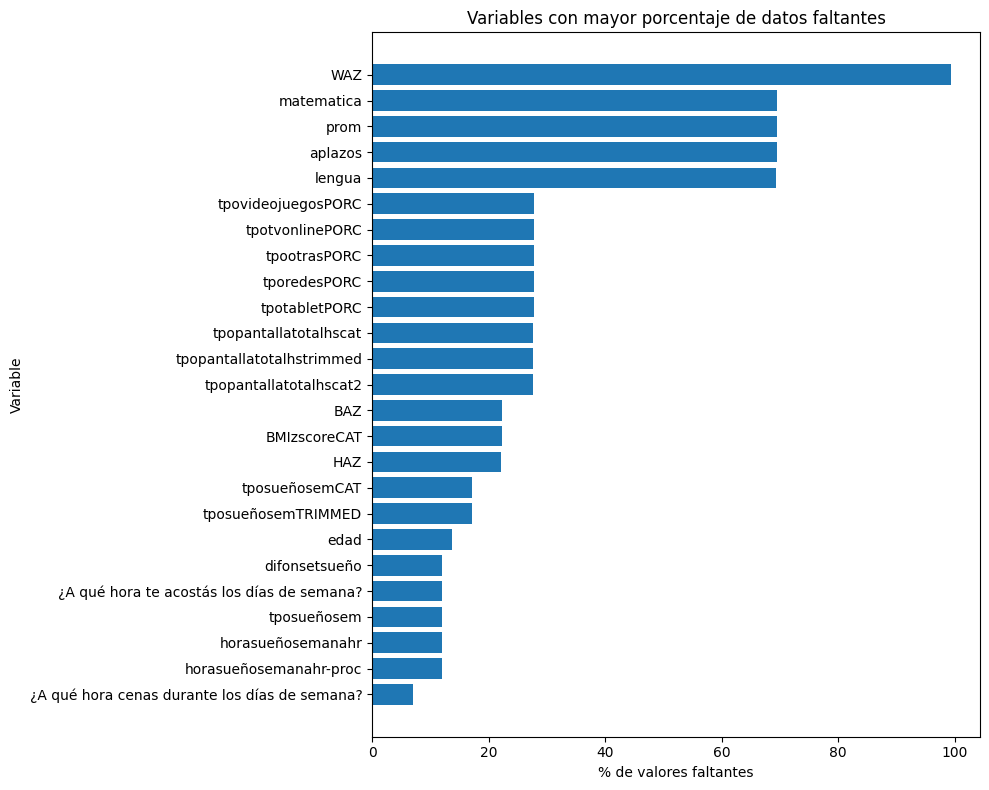

In [19]:
missing = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("porcentaje", ascending=False)

display(missing.head(30))

# Visualización de las variables con mayor porcentaje de faltantes
top_missing = missing.head(25).sort_values("porcentaje")

plt.figure(figsize=(10, 8))
plt.barh(top_missing.index, top_missing["porcentaje"])
plt.xlabel("% de valores faltantes")
plt.ylabel("Variable")
plt.title("Variables con mayor porcentaje de datos faltantes")
plt.tight_layout()
plt.show()

### Criterio de tratamiento de faltantes

No se aplicará una única regla global de imputación. La decisión dependerá de la función de la variable:

- Si una variable es indispensable para formar los clusters, se evaluará su proporción de faltantes y la conveniencia de trabajar con casos completos o imputación.
- Si una variable se utiliza solamente para caracterizar clusters, un faltante no necesariamente obliga a excluir el registro del clustering.
- Las variables con faltantes extremadamente altos serán analizadas antes de decidir su permanencia.

## 6.2 Duplicados

In [24]:
duplicados_exactos = df.duplicated().sum()
print("Filas completamente duplicadas:", duplicados_exactos)

for id_col in ["Submission ID", "Código"]:
    if id_col in df.columns:
        dup = df[id_col].duplicated(keep=False)
        print(f"{id_col}: {dup.sum()} registros involucrados en valores duplicados")
        if dup.any():
            display(df.loc[dup, [id_col]].sort_values(id_col).head(20))

Filas completamente duplicadas: 0
Submission ID: 0 registros involucrados en valores duplicados
Código: 2 registros involucrados en valores duplicados


,Código
2573,10 19 48 2 1 IR 0 131004
2574,10 19 48 2 1 IR 0 131004


In [25]:
display(Markdown(f'''
### Interpretación de duplicados

Se detectaron **{duplicados_exactos} filas completamente duplicadas**.

Los identificadores deben analizarse por separado porque un valor repetido podría representar una carga duplicada, pero también podría deberse a un criterio administrativo.
'''))


### Interpretación de duplicados

Se detectaron **0 filas completamente duplicadas**.

Los identificadores deben analizarse por separado porque un valor repetido podría representar una carga duplicada, pero también podría deberse a un criterio administrativo.


## 6.3 Búsqueda de errores, textos especiales e inconsistencias

In [23]:
errores_busqueda = [
    "#NAME?", "#VALUE!", "#REF!", "#DIV/0!", "#N/A",
    "Sin información", "sin informacion", "inf", "-inf"
]

hallazgos = []

for c in df.columns:
    s = df[c].astype(str)
    for patron in errores_busqueda:
        mask = s.str.contains(re.escape(patron), case=False, na=False)
        if mask.any():
            hallazgos.append({
                "variable": c,
                "patron": patron,
                "cantidad": int(mask.sum())
            })

hallazgos_df = pd.DataFrame(hallazgos)

if len(hallazgos_df):
    display(hallazgos_df.sort_values("cantidad", ascending=False))
else:
    print("No se encontraron los patrones de error buscados en los valores cargados por pandas.")
    print("Nota: si el Excel contiene fórmulas rotas, pandas puede leer el valor almacenado o NaN dependiendo del archivo.")

,variable,patron,cantidad
0,FECHA_NAC_RECOD,Sin información,535
1,FECHA_NAC_RECOD,inf,535


In [26]:
# Infinitos en variables numéricas
num_cols = df.select_dtypes(include=np.number).columns
inf_counts = {}

for c in num_cols:
    n_inf = np.isinf(df[c].to_numpy(dtype=float, na_value=np.nan)).sum()
    if n_inf > 0:
        inf_counts[c] = int(n_inf)

print("Variables con valores infinitos:")
print(inf_counts if inf_counts else "Ninguna")

Variables con valores infinitos:
Ninguna


## 6.4 Indicadores de completitud y exclusión

El dataset incluye indicadores construidos durante el procesamiento original. Estos indicadores se analizarán, pero no se utilizarán ciegamente como filtro, ya que nuestro objetivo de clustering puede requerir criterios diferentes del estudio original.

In [28]:
cols_indicadores = [
    "datoscompletoDEMOG",
    "datoscompletoSUENO",
    "datoscompletoPANTALLAS",
    "excSUENOpantallas",
    "excluidos",
    "missingnotas",
    "excluFINAL",
]
cols_indicadores = [c for c in cols_indicadores if c in df.columns]

for c in cols_indicadores:
    print(f"\n{c}")
    display(
        df[c]
        .value_counts(dropna=False)
        .rename("cantidad")
        .to_frame()
        .assign(porcentaje=lambda x: x["cantidad"] / len(df) * 100)
    )


datoscompletoDEMOG


,cantidad,porcentaje
datoscompletoDEMOG,,
1,3553,86.342649
0,562,13.657351



datoscompletoSUENO


,cantidad,porcentaje
datoscompletoSUENO,,
1,3220,78.250304
0,895,21.749696



datoscompletoPANTALLAS


...

,cantidad,porcentaje
excluidos,,
0,2449,59.513973
1,1666,40.486027



missingnotas


,cantidad,porcentaje
missingnotas,,
1,2858,69.45322
0,1257,30.54678



excluFINAL


,cantidad,porcentaje
excluFINAL,,
1,3251,79.003645
0,864,20.996355


In [30]:
if "datoscompletoPANTALLAS" in df.columns and "excluFINAL" in df.columns:
    print("Cruce datos completos de pantallas vs exclusión final:")
    display(pd.crosstab(
        df["datoscompletoPANTALLAS"],
        df["excluFINAL"],
        margins=True,
        normalize=False
    ))

Cruce datos completos de pantallas vs exclusión final:


excluFINAL,0,1,All
datoscompletoPANTALLAS,,,
0,0,537,537
1,864,2714,3578
All,864,3251,4115


#### Nota:
Este Analisis nos permite verificar la coherencia lógica de la limpieza de datos original. Por ejemplo, nos ayuda a comprobar si todos los participantes que tenían datos de pantallas incompletos terminaron siendo excluidos del análisis final, o si hay participantes con datos completos que aun así fueron descartados por otros motivos (como inconsistencias de edad o falta de datos en otras áreas).

### Criterio metodológico

Un registro sin notas académicas podría seguir siendo totalmente válido para formar clusters de comportamiento digital. De igual manera, un registro con información de pantallas completa pero con datos de sueño incompletos podría servir para el clustering y quedar parcialmente disponible para caracterización.

Por eso se distinguirá entre:

1. **criterios mínimos para clusterización**, y
2. **disponibilidad de variables de caracterización**.

# 7 Análisis Exploratorio de Datos

## 7.1 Características demográficas

,edad
count,3553.000000
mean,15.600338
std,1.601527
min,12.000000
1%,12.000000
5%,13.000000
25%,14.000000
50%,16.000000
75%,17.000000
95%,18.000000



Distribución de edad:


,cantidad
edad,
12.0,72
13.0,294
14.0,591
15.0,715
16.0,736
17.0,707
18.0,385
19.0,42
20.0,11


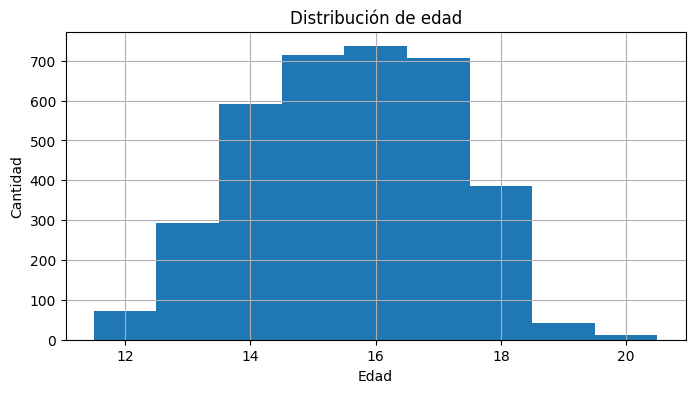

,cantidad
Sexo,
Femenino,2277
Masculino,1838


,cantidad
grado,
1,712
2,761
3,814
4,833
5,745
6,250


In [31]:
# Edad
if "edad" in df.columns:
    display(df["edad"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame())

    print("\nDistribución de edad:")
    display(df["edad"].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())

    plt.figure(figsize=(8, 4))
    df["edad"].dropna().hist(bins=range(
        int(df["edad"].dropna().min()),
        int(df["edad"].dropna().max()) + 2
    ), align="left")
    plt.xlabel("Edad")
    plt.ylabel("Cantidad")
    plt.title("Distribución de edad")
    plt.show()

# Sexo
if "Sexo" in df.columns:
    display(df["Sexo"].value_counts(dropna=False).rename("cantidad").to_frame())

# Grado
if "grado" in df.columns:
    display(df["grado"].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())

In [32]:
if "edad" in df.columns:
    menores_12 = int((df["edad"] < 12).sum())
    entre_12_18 = int(df["edad"].between(12, 18, inclusive="both").sum())
    mayores_18 = int((df["edad"] > 18).sum())
    edad_missing = int(df["edad"].isna().sum())

    display(Markdown(f'''
### Interpretación de edad

- Menores de 12 años: **{menores_12}**
- Entre 12 y 18 años: **{entre_12_18}**
- Mayores de 18 años: **{mayores_18}**
- Edad faltante: **{edad_missing}**

La documentación del estudio indica una población adolescente de aproximadamente 12 a 18 años. Los registros fuera de ese rango no se eliminan todavía: primero deben evaluarse junto con indicadores de completitud/exclusión y el resto de la información disponible.
'''))


### Interpretación de edad

- Menores de 12 años: **0**
- Entre 12 y 18 años: **3500**
- Mayores de 18 años: **53**
- Edad faltante: **562**

La documentación del estudio indica una población adolescente de aproximadamente 12 a 18 años. Los registros fuera de ese rango no se eliminan todavía: primero deben evaluarse junto con indicadores de completitud/exclusión y el resto de la información disponible.


## 7.2 Consumo digital

In [101]:
vars_consumo_original = [
    "tpovideojuegoshs",
    "tpojuegotabletcelhs",
    "tporedeshs",
    "tpotvonlinehs",
    "tpootrashs",
    "tpopantallatotalhs",
]

vars_consumo_trimmed = [
    "tpovideojuegoshstrimmed",
    "tpojuegotabletcelhstrimmed",
    "tporedeshstrimmed",
    "tpotvonlinehstrimeed",
    "tpootrashstrimed",
    "tpopantallatotalhstrimmed",
]

vars_consumo_original = [c for c in vars_consumo_original if c in df.columns]
vars_consumo_trimmed = [c for c in vars_consumo_trimmed if c in df.columns]

print("Variables originales:")
print(vars_consumo_original)

print("\nVariables tratadas/trimmed:")
print(vars_consumo_trimmed)

Variables originales:
['tpovideojuegoshs', 'tpojuegotabletcelhs', 'tporedeshs', 'tpotvonlinehs', 'tpootrashs', 'tpopantallatotalhs']

Variables tratadas/trimmed:
['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed', 'tpotvonlinehstrimeed', 'tpootrashstrimed', 'tpopantallatotalhstrimmed']


In [87]:
# Información estadística descriptiva detallada, para entender cómo se comporta
# el consumo digital en el grupo de adolescentes
def resumen_numerico(dataframe, columnas):
    columnas = [c for c in columnas if c in dataframe.columns]
    if not columnas:
        return pd.DataFrame()
    return dataframe[columnas].describe(
        percentiles=[.01, .05, .25, .5, .75, .95, .99]
    ).T

display(resumen_numerico(df, vars_consumo_original))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tpovideojuegoshs,4115.0,1.128919,2.448686,0.0,0.0,0.000000,0.000000,0.0,1.333333,5.0,10.620000,23.833333
tpojuegotabletcelhs,4115.0,2.309599,3.638319,0.0,0.0,0.000000,0.166667,1.0,3.000000,9.0,20.000000,23.833333
tporedeshs,4115.0,4.119603,4.734305,0.0,0.0,0.166667,1.000000,3.0,5.000000,14.6,23.833333,23.833333
tpotvonlinehs,4115.0,3.006278,3.607642,0.0,0.0,0.000000,1.000000,2.0,3.500000,9.0,23.000000,23.833333
tpootrashs,4115.0,1.204536,3.061070,0.0,0.0,0.000000,0.000000,0.0,1.000000,5.0,20.000000,23.833333


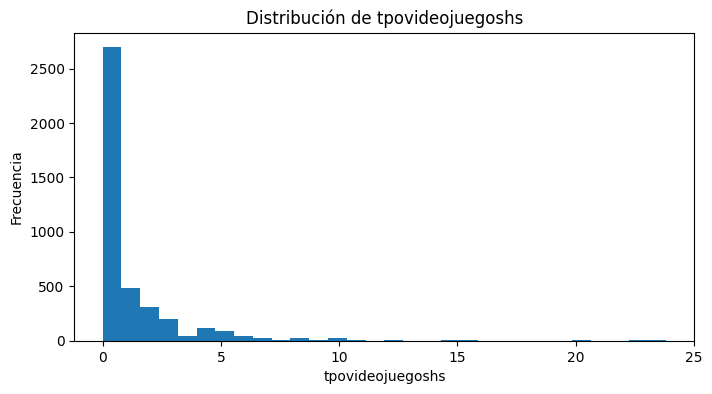

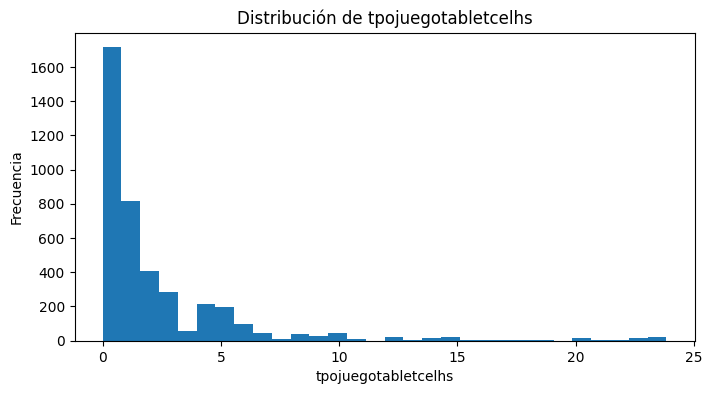

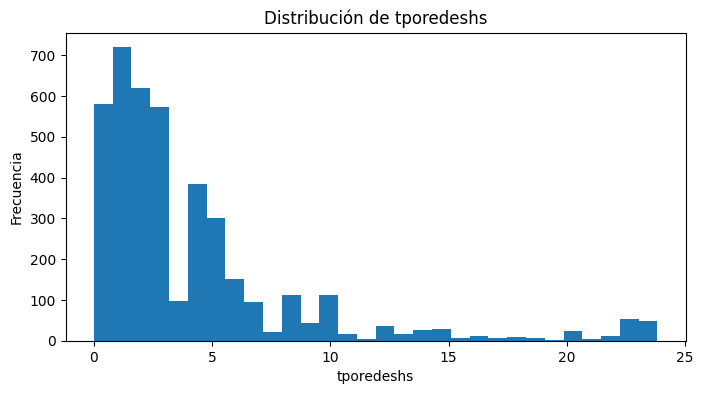

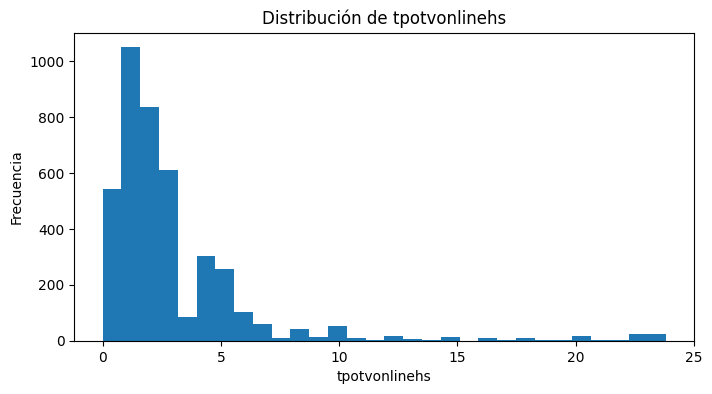

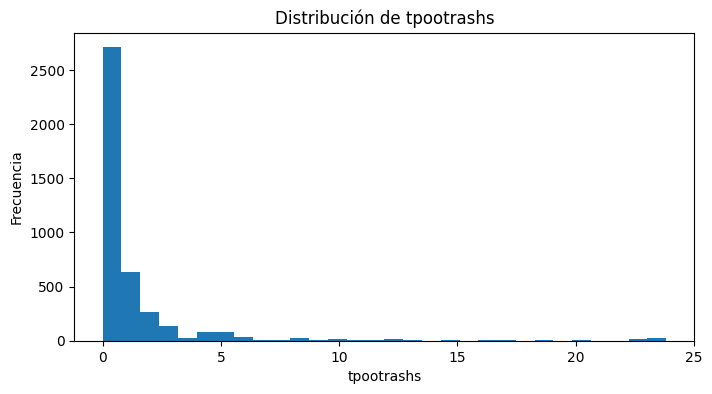

In [88]:
# Histogramas de las principales variables de consumo
for c in vars_consumo_original:
    serie = pd.to_numeric(df[c], errors="coerce")
    plt.figure(figsize=(8, 4))
    plt.hist(serie.dropna(), bins=30)
    plt.title(f"Distribución de {c}")
    plt.xlabel(c)
    plt.ylabel("Frecuencia")
    plt.show()

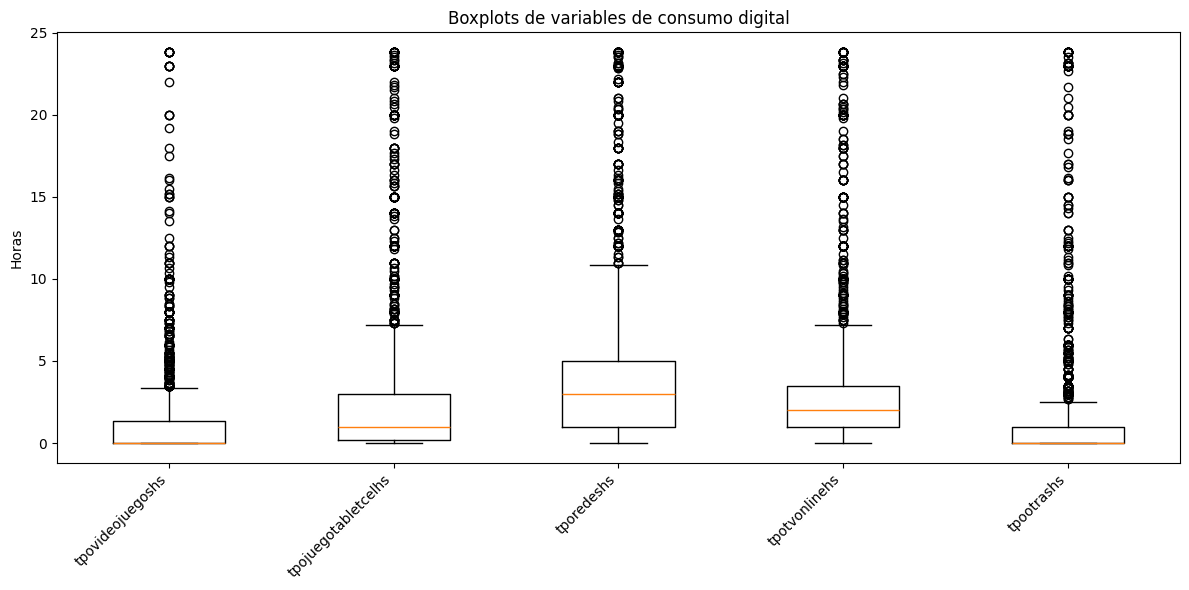

In [89]:
# Boxplots de consumo digital
if vars_consumo_original:
    datos_plot = df[vars_consumo_original].apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(12, 6))
    plt.boxplot(
        [datos_plot[c].dropna() for c in vars_consumo_original],
        tick_labels=vars_consumo_original,
        showfliers=True
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Horas")
    plt.title("Boxplots de variables de consumo digital")
    plt.tight_layout()
    plt.show()

## 7.3 Validación del tiempo total de pantalla

Se comprobará si el tiempo total de pantalla coincide con la suma de sus componentes. Esta validación permite detectar inconsistencias y decidir si conviene utilizar el total provisto, reconstruirlo o trabajar directamente con los componentes.

In [90]:
componentes = [
    "tpovideojuegoshs",
    "tpojuegotabletcelhs",
    "tporedeshs",
    "tpotvonlinehs",
    "tpootrashs",
]
componentes = [c for c in componentes if c in df.columns]

if "tpopantallatotalhs" in df.columns and len(componentes) >= 2:
    suma_componentes = df[componentes].sum(axis=1, min_count=len(componentes))
    diferencia = df["tpopantallatotalhs"] - suma_componentes

    validacion_total = pd.DataFrame({
        "total_reportado": df["tpopantallatotalhs"],
        "suma_componentes": suma_componentes,
        "diferencia": diferencia
    })

    tolerancia = 0.05

    print("Resumen de la diferencia total - suma de componentes:")
    display(diferencia.describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())

    consistentes = diferencia.abs() <= tolerancia
    n_validos = diferencia.notna().sum()
    n_consistentes = consistentes.sum()

    if n_validos:
        print(f"Registros comparables: {n_validos}")
        print(f"Consistentes dentro de ±{tolerancia}: {n_consistentes} ({n_consistentes/n_validos*100:.2f}%)")

    print("\nCasos con mayores discrepancias:")
    display(validacion_total.loc[diferencia.abs().sort_values(ascending=False).head(15).index])

Resumen de la diferencia total - suma de componentes:


,0
count,4115.0
mean,0.0
std,0.0
min,0.0
1%,0.0
5%,0.0
50%,0.0
95%,0.0
99%,0.0
max,0.0


Registros comparables: 4115
Consistentes dentro de ±0.05: 4115 (100.00%)

Casos con mayores discrepancias:


,total_reportado,suma_componentes,diferencia
4114,8.833333,8.833333,0.0
0,11.000000,11.000000,0.0
1,10.500000,10.500000,0.0
4098,5.666667,5.666667,0.0
4097,15.500000,15.500000,0.0
4096,4.000000,4.000000,0.0
4095,6.000000,6.000000,0.0
4094,5.666667,5.666667,0.0
4093,4.500000,4.500000,0.0
4092,2.500000,2.500000,0.0


## 7.4 Composición porcentual del consumo digital

In [91]:
vars_porcentajes = [
    "tpovideojuegosPORC",
    "tpotabletPORC",
    "tporedesPORC",
    "tpotvonlinePORC",
    "tpootrasPORC",
]
vars_porcentajes = [c for c in vars_porcentajes if c in df.columns]

if vars_porcentajes:
    display(resumen_numerico(df, vars_porcentajes))

    suma_porc = df[vars_porcentajes].sum(axis=1, min_count=len(vars_porcentajes))
    print("\nResumen de la suma de porcentajes:")
    display(suma_porc.describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())

    problemas_porc = pd.DataFrame({
        "suma_porcentajes": suma_porc,
        "menor_que_99": suma_porc < 99,
        "mayor_que_101": suma_porc > 101,
    })

    print("Cantidad con suma < 99:", problemas_porc["menor_que_99"].sum())
    print("Cantidad con suma > 101:", problemas_porc["mayor_que_101"].sum())

    for c in vars_porcentajes:
        print(
            f"{c}: negativos={(df[c] < 0).sum()}, "
            f">100={(df[c] > 100).sum()}, "
            f"missing={df[c].isna().sum()}"
        )

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tpovideojuegosPORC,2969.0,9.374958,16.114084,0.0,0.0,0.000000,0.000000,0.000000,15.254237,45.953177,66.666664,89.189188
tpotabletPORC,2969.0,17.604126,17.653831,0.0,0.0,0.000000,0.000000,13.043476,28.571427,50.000000,67.047622,100.000000
tporedesPORC,2969.0,36.675647,22.428659,0.0,0.0,2.873705,19.999998,33.333334,50.000000,77.777776,94.897243,100.000000
tpotvonlinePORC,2969.0,29.400741,18.280185,0.0,0.0,0.000000,16.666664,27.272727,40.000000,62.500000,80.000002,100.000000
tpootrasPORC,2969.0,6.944527,12.242976,0.0,0.0,0.000000,0.000000,0.000000,10.526316,32.851027,53.721212,100.000000



Resumen de la suma de porcentajes:


,0
count,2.969000e+03
mean,1.000000e+02
std,9.718136e-15
min,1.000000e+02
1%,1.000000e+02
5%,1.000000e+02
50%,1.000000e+02
95%,1.000000e+02
99%,1.000000e+02
max,1.000000e+02


Cantidad con suma < 99: 0
Cantidad con suma > 101: 0
tpovideojuegosPORC: negativos=0, >100=0, missing=1146
tpotabletPORC: negativos=0, >100=0, missing=1146
tporedesPORC: negativos=0, >100=0, missing=1146
tpotvonlinePORC: negativos=0, >100=0, missing=1146
tpootrasPORC: negativos=0, >100=0, missing=1146


### Consideración metodológica sobre porcentajes

Las variables porcentuales representan la **composición** del tiempo digital y pueden ser especialmente útiles para descubrir perfiles según la actividad predominante.

Sin embargo, si las proporciones suman aproximadamente 100%, existe una dependencia matemática entre ellas. Por este motivo, en un experimento basado exclusivamente en composición puede ser conveniente eliminar una de las proporciones o utilizar técnicas específicas para datos composicionales. En este TP se documentará esta limitación y se evitará mezclar indiscriminadamente porcentajes con sus horas originales.

## 7.5 Frecuencia de uso de dispositivos

In [92]:
vars_dispositivos_raw = [
    "PC o Laptop", "Teléfono celular 2", "Tablet",
    "Consola de juegos", "TV o Smart TV"
]

vars_dispositivos_trimmed = [
    "cantdiascompustrimmed",
    "cantdiascelulartrimmed",
    "cantdiastablettrimmed",
    "cantdiasconsolajuegostrimmed",
    "cantdiastvtrimmed",
]

vars_dispositivos_bin = [
    "cantdiascompus01",
    "cantdiascelular01",
    "cantdiastablet01",
    "cantdiasconsolajuegos01",
    "cantdiastv01",
]

for grupo, columnas in {
    "Originales": vars_dispositivos_raw,
    "Tratadas": vars_dispositivos_trimmed,
    "Binarias": vars_dispositivos_bin
}.items():
    disponibles = [c for c in columnas if c in df.columns]
    print(f"\n{grupo}:")
    if disponibles:
        display(resumen_numerico(df, disponibles))


Originales:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
PC o Laptop,4115.0,0.915674,1.792854,0.0,0.0,0.0,0.0,0.0,1.0,5.0,7.0,9.0
Teléfono celular 2,4115.0,5.948967,2.126601,0.0,0.0,1.0,5.0,7.0,7.0,8.0,9.0,9.0
Tablet,4115.0,0.379830,1.295380,0.0,0.0,0.0,0.0,0.0,0.0,3.0,7.0,9.0
Consola de juegos,4115.0,0.754800,1.693994,0.0,0.0,0.0,0.0,0.0,0.0,5.0,7.0,9.0
TV o Smart TV,4115.0,2.715917,2.639262,0.0,0.0,0.0,0.0,2.0,5.0,7.0,9.0,9.0



Tratadas:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
cantdiascompustrimmed,4097.0,0.880644,1.716805,0.0,0.0,0.0,0.0,0.0,1.0,5.0,7.0,7.0
cantdiascelulartrimmed,3907.0,5.799335,2.076166,0.0,0.0,1.0,5.0,7.0,7.0,7.0,7.0,7.0
cantdiastablettrimmed,4105.0,0.359562,1.229836,0.0,0.0,0.0,0.0,0.0,0.0,3.0,7.0,7.0
cantdiasconsolajuegostrimmed,4089.0,0.704084,1.574623,0.0,0.0,0.0,0.0,0.0,0.0,5.0,7.0,7.0
cantdiastvtrimmed,4056.0,2.627959,2.554346,0.0,0.0,0.0,0.0,2.0,5.0,7.0,7.0,7.0



Binarias:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
cantdiascompus01,4115.0,0.312758,0.463673,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
cantdiascelular01,4115.0,0.971810,0.165534,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cantdiastablet01,4115.0,0.116889,0.321328,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
cantdiasconsolajuegos01,4115.0,0.236695,0.425105,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
cantdiastv01,4115.0,0.683597,0.465129,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


## 7.6 Uso de pantallas cerca del horario de dormir

In [93]:
vars_bedtime = [
    "WATCHTVbedtime7D01",
    "COMPUbedtime1D01",
    "COMPUbedtime2D01",
]

vars_bedtime = [c for c in vars_bedtime if c in df.columns]

for c in vars_bedtime:
    print(f"\n{c}")
    display(df[c].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())


WATCHTVbedtime7D01


,cantidad
WATCHTVbedtime7D01,
0,3453
1,662



COMPUbedtime1D01


,cantidad
COMPUbedtime1D01,
0,3704
1,411



COMPUbedtime2D01


,cantidad
COMPUbedtime2D01,
0,3792
1,323


## 7.7 Sueño

In [94]:
vars_sueno = [
    "dursiestasemanahs",
    "¿Cuánto tiempo de pantalla (dispositivos electrónicos) utilizas antes de dormirte los días de semana?",
    "horacenahr",
    "horasueñosemanahr-proc",
    "horasueñosemanahr",
    "¿Cuánto tiempo en Minutos tardas en dormirte?",
    "horalevantarsesemanahr",
    "tposueñosem",
    "tposueñosemTRIMMED",
    "horaacostarfsemanahr",
    "horalevantarsefsemanahr-proc",
    "tpofsueñosem",
    "tposueñofsemTRIMMED",
    "difonsetsueño",
]
vars_sueno = [c for c in vars_sueno if c in df.columns]

display(resumen_numerico(df, vars_sueno))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
dursiestasemanahs,4115.0,1.317375,2.102711,0.000000,0.000000e+00,0.000000,0.000000,0.166667,2.000000,5.000000,8.833333,23.833333
¿Cuánto tiempo de pantalla (dispositivos electrónicos) utilizas antes de dormirte los días de semana?,4115.0,1.146497,2.431514,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.500000,5.000000,11.930000,23.833333
horacenahr,3826.0,21.510716,0.937604,19.500000,1.950000e+01,20.500000,20.500000,21.500000,22.500000,23.500000,23.500000,24.500000
horasueñosemanahr-proc,3624.0,21.662804,3.288331,13.500000,1.350000e+01,13.500000,21.500000,22.500000,23.500000,24.500000,24.500000,24.500000
horasueñosemanahr,3624.0,23.477373,1.437457,19.500000,2.050000e+01,21.500000,22.500000,23.500000,23.500000,26.500000,27.500000,30.500000
¿Cuánto tiempo en Minutos tardas en dormirte?,4115.0,22.369016,36.071497,0.000000,1.000000e+00,3.000000,10.000000,15.000000,30.000000,60.000000,128.600000,999.000000
horalevantarsesemanahr,4115.0,6.710288,1.024273,0.000000,5.000000e+00,5.833333,6.333333,6.666667,7.000000,7.550000,10.500000,23.833333
tposueñosem,3624.0,6.851534,1.770053,-10.150000,1.500000e+00,3.833333,6.166667,7.000000,7.833333,8.950000,10.730833,24.000000
tposueñosemTRIMMED,3411.0,7.057864,1.230224,4.000000,4.166667e+00,4.833333,6.333333,7.083333,7.833333,8.916667,10.166667,11.883333
horaacostarfsemanahr,4115.0,25.469907,2.253659,19.000000,1.916667e+01,22.000000,23.833333,25.500000,27.000000,29.500000,30.310000,30.833333


In [42]:
# Comparar variables de duración de sueño originales y trimmed
pares_trimmed_sueno = [
    ("tposueñosem", "tposueñosemTRIMMED"),
    ("tpofsueñosem", "tposueñofsemTRIMMED"),
]

for original, trimmed in pares_trimmed_sueno:
    if original in df.columns and trimmed in df.columns:
        print(f"\n{original} vs {trimmed}")
        comparacion = pd.DataFrame({
            original: df[original],
            trimmed: df[trimmed],
        })
        print("Original:")
        display(df[original].describe(percentiles=[.01,.05,.5,.95,.99]).to_frame())
        print("Trimmed:")
        display(df[trimmed].describe(percentiles=[.01,.05,.5,.95,.99]).to_frame())
        print("Registros donde trimmed es NaN pero original no:",
              (df[trimmed].isna() & df[original].notna()).sum())


tposueñosem vs tposueñosemTRIMMED
Original:


,tposueñosem
count,3624.000000
mean,6.851534
std,1.770053
min,-10.150000
1%,1.500000
5%,3.833333
50%,7.000000
95%,8.950000
99%,10.730833
max,24.000000


Trimmed:


,tposueñosemTRIMMED
count,3411.000000
mean,7.057864
std,1.230224
min,4.000000
1%,4.166667
5%,4.833333
50%,7.083333
95%,8.916667
99%,10.166667
max,11.883333


Registros donde trimmed es NaN pero original no: 213

tpofsueñosem vs tposueñofsemTRIMMED
Original:


,tpofsueñosem
count,4115.000000
mean,9.176063
std,3.136769
min,-5.333333
1%,-2.500000
5%,4.783333
50%,9.333333
95%,13.000000
99%,18.000000
max,24.000000


Trimmed:


,tposueñofsemTRIMMED
count,3864.000000
mean,9.291667
std,2.011884
min,1.000000
1%,3.876667
5%,6.000000
50%,9.500000
95%,12.500000
99%,13.500000
max,14.000000


Registros donde trimmed es NaN pero original no: 251


## 7.8 Somnolencia / PDSS

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Resultado,4115.0,18.653220,5.172807,2.0,7.0,10.0,15.0,19.0,22.0,27.0,29.0,32.0
somno01pdss,4115.0,0.719320,0.449386,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
problemasatencionrecod,4115.0,2.173269,1.044403,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0
¿Con qué frecuencia te quedás dormido/a o te da sueño mientras hacés la tarea?,4115.0,1.406561,1.251817,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,4.0
¿Estás atento/a o alerta en clase?,4115.0,3.019927,0.843397,0.0,0.0,1.0,3.0,3.0,4.0,4.0,4.0,4.0
¿Con qué frecuencia te sentís cansado y de mal humor durante el día?,4115.0,2.147995,1.084302,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0
¿Te cuesta levantarte de la cama a la mañana?,4115.0,2.906197,1.280894,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0,4.0
¿Te volvés a quedar dormido/a después de que te despertaron a la mañana?,4115.0,1.807776,1.471736,0.0,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0
¿Necesitás que alguien te despierte por la mañana?,4115.0,2.324423,1.680907,0.0,0.0,0.0,0.0,3.0,4.0,4.0,4.0,4.0
¿Con qué frecuencia sentís que necesitás dormir más tiempo?,4115.0,2.867072,1.116270,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0,4.0


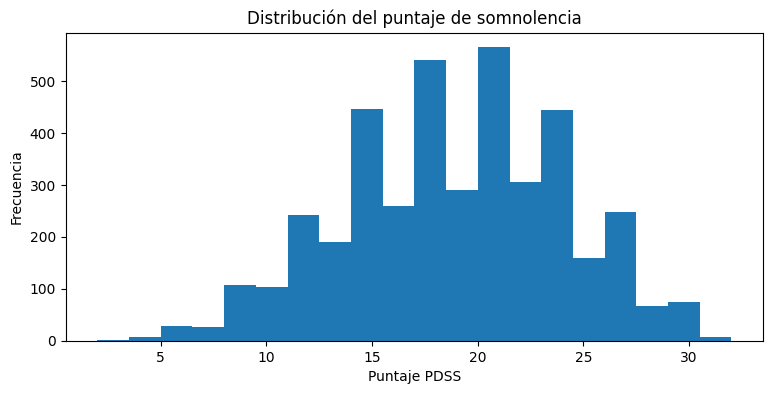

PDSS según indicador binario:


,count,mean,std,min,25%,50%,75%,max
somno01pdss,,,,,,,,
0,1155.0,12.234632,2.528420,2.0,11.0,13.0,14.0,15.0
1,2960.0,21.157770,3.514722,16.0,18.0,21.0,24.0,32.0


In [95]:
vars_pdss = [
    "Resultado",
    "somno01pdss",
    "problemasatencionrecod",
    "¿Con qué frecuencia te quedás dormido/a o te da sueño mientras hacés la tarea?",
    "¿Estás atento/a o alerta en clase?",
    "¿Con qué frecuencia te sentís cansado y de mal humor durante el día?",
    "¿Te cuesta levantarte de la cama a la mañana?",
    "¿Te volvés a quedar dormido/a después de que te despertaron a la mañana?",
    "¿Necesitás que alguien te despierte por la mañana?",
    "¿Con qué frecuencia sentís que necesitás dormir más tiempo?",
]
vars_pdss = [c for c in vars_pdss if c in df.columns]

display(resumen_numerico(df, vars_pdss))

if "Resultado" in df.columns:
    plt.figure(figsize=(9, 4))
    plt.hist(df["Resultado"].dropna(), bins=20)
    plt.xlabel("Puntaje PDSS")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del puntaje de somnolencia")
    plt.show()

if "Resultado" in df.columns and "somno01pdss" in df.columns:
    print("PDSS según indicador binario:")
    display(df.groupby("somno01pdss")["Resultado"].describe())

## 7.9 Rendimiento académico

In [44]:
vars_academicas = [
    "lengua", "matematica", "prom", "aplazos", "missingnotas"
]
vars_academicas = [c for c in vars_academicas if c in df.columns]

display(resumen_numerico(df, vars_academicas))

for c in vars_academicas:
    print(f"{c}: missing = {df[c].isna().sum()} ({df[c].isna().mean()*100:.2f}%)")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
lengua,1261.0,7.439453,1.457938,1.0,4.0,5.0,6.66,8.0,8.5,10.0,10.00,10.0
matematica,1257.0,7.175123,1.804322,1.0,2.0,4.0,6.00,7.0,9.0,10.0,10.00,10.0
prom,1257.0,7.308385,1.440699,2.0,3.5,4.5,6.50,7.5,8.5,9.5,9.72,10.0
aplazos,1257.0,0.430390,0.495328,0.0,0.0,0.0,0.00,0.0,1.0,1.0,1.00,1.0
missingnotas,4115.0,0.694532,0.460661,0.0,0.0,0.0,0.00,1.0,1.0,1.0,1.00,1.0


lengua: missing = 2854 (69.36%)
matematica: missing = 2858 (69.45%)
prom: missing = 2858 (69.45%)
aplazos: missing = 2858 (69.45%)
missingnotas: missing = 0 (0.00%)


### Interpretación metodológica del rendimiento académico

Las variables académicas se consideran de **caracterización**, no variables principales para formar clusters de consumo digital.

La ausencia de notas no debería excluir automáticamente un adolescente del clustering si dispone de información suficiente sobre comportamiento digital.

## 8 Detección de valores extremos

Un valor extremo estadístico no es necesariamente un error. Se utilizará el método IQR como herramienta de diagnóstico, pero las decisiones se tomarán considerando también la semántica de cada variable.

In [96]:
def detectar_outliers_iqr(dataframe, columnas):
    filas = []

    for c in columnas:
        if c not in dataframe.columns:
            continue

        s = pd.to_numeric(dataframe[c], errors="coerce").dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr

        mask = (s < limite_inf) | (s > limite_sup)

        filas.append({
            "variable": c,
            "min": s.min(),
            "q1": q1,
            "mediana": s.median(),
            "q3": q3,
            "max": s.max(),
            "limite_inferior_iqr": limite_inf,
            "limite_superior_iqr": limite_sup,
            "cantidad_outliers_iqr": int(mask.sum()),
            "porcentaje_outliers_iqr": mask.mean() * 100,
        })

    return pd.DataFrame(filas)

vars_outliers = list(dict.fromkeys(
    vars_consumo_original
    + vars_sueno
    + ["tpoviajemin", "Altura en m", "Peso en kg", "imc"]
))

tabla_outliers = detectar_outliers_iqr(df, vars_outliers)

display(
    tabla_outliers.sort_values(
        "porcentaje_outliers_iqr", ascending=False
    ).reset_index(drop=True)
)

,variable,min,q1,mediana,q3,max,limite_inferior_iqr,limite_superior_iqr,cantidad_outliers_iqr,porcentaje_outliers_iqr
0,horasueñosemanahr,19.500000,22.500000,23.500000,23.500000,30.500000,21.000000,25.000000,594,16.390728
1,horasueñosemanahr-proc,13.500000,21.500000,22.500000,23.500000,24.500000,18.500000,26.500000,540,14.900662
2,difonsetsueño,0.000000,1.000000,2.500000,4.500000,17.166667,-4.250000,9.750000,487,13.438190
3,tpoviajemin,0.000000,10.000000,15.000000,30.000000,5400.000000,-20.000000,60.000000,495,12.029162
4,tpootrashs,0.000000,0.000000,0.000000,1.000000,23.833333,-1.500000,2.500000,483,11.737546
5,tpovideojuegoshs,0.000000,0.000000,0.000000,1.333333,23.833333,-2.000000,3.333334,418,10.157959
6,¿Cuánto tiempo de pantalla (dispositivos elect...,0.000000,0.000000,0.000000,1.500000,23.833333,-2.250000,3.750000,385,9.356015
7,tporedeshs,0.000000,1.000000,3.000000,5.000000,23.833333,-5.000000,11.000000,293,7.120292
8,tpojuegotabletcelhs,0.000000,0.166667,1.000000,3.000000,23.833333,-4.083334,7.250000,273,6.634265
9,tpotvonlinehs,0.000000,1.000000,2.000000,3.500000,23.833333,-2.750000,7.250000,267,6.488457


### Criterio de decisión sobre outliers

Los outliers IQR se mantendrán por defecto. Se eliminarán o corregirán solamente cuando:

- sean físicamente imposibles;
- correspondan claramente a errores de carga;
- exista evidencia de una conversión incorrecta;
- el estudio original ya cuente con una versión tratada cuya lógica pueda interpretarse.

Para las variables de consumo digital, se compararán especialmente las versiones originales con las versiones `trimmed`.

## 9 Relaciones entre variables y redundancia

In [97]:
# Correlación de variables numéricas relevantes
vars_corr = list(dict.fromkeys(
    vars_consumo_original
    + vars_consumo_trimmed
    + vars_porcentajes
    + vars_dispositivos_trimmed
    + ["edad", "Resultado", "tposueñosemTRIMMED", "tposueñofsemTRIMMED"]
))
vars_corr = [c for c in vars_corr if c in df.columns]

corr = df[vars_corr].corr(numeric_only=True)

# Mostrar correlaciones absolutas altas excluyendo diagonal
pares_corr = []
for i, c1 in enumerate(corr.columns):
    for j, c2 in enumerate(corr.columns):
        if j <= i:
            continue
        valor = corr.loc[c1, c2]
        if pd.notna(valor) and abs(valor) >= 0.90:
            pares_corr.append({
                "variable_1": c1,
                "variable_2": c2,
                "correlacion": valor
            })

pares_corr_df = pd.DataFrame(pares_corr)

if len(pares_corr_df):
    display(
        pares_corr_df.assign(
            abs_corr=lambda x: x["correlacion"].abs()
        ).sort_values("abs_corr", ascending=False).drop(columns="abs_corr")
    )
else:
    print("No se encontraron pares con |r| >= 0.90 entre las variables seleccionadas.")

,variable_1,variable_2,correlacion
0,tpovideojuegoshs,tpovideojuegoshstrimmed,1.000000
2,tpojuegotabletcelhs,tpojuegotabletcelhstrimmed,1.000000
3,tporedeshs,tporedeshstrimmed,1.000000
5,tpootrashs,tpootrashstrimed,1.000000
4,tpotvonlinehs,tpotvonlinehstrimeed,1.000000
1,tpovideojuegoshs,tpovideojuegosPORC,0.902829
6,tpovideojuegoshstrimmed,tpovideojuegosPORC,0.902829


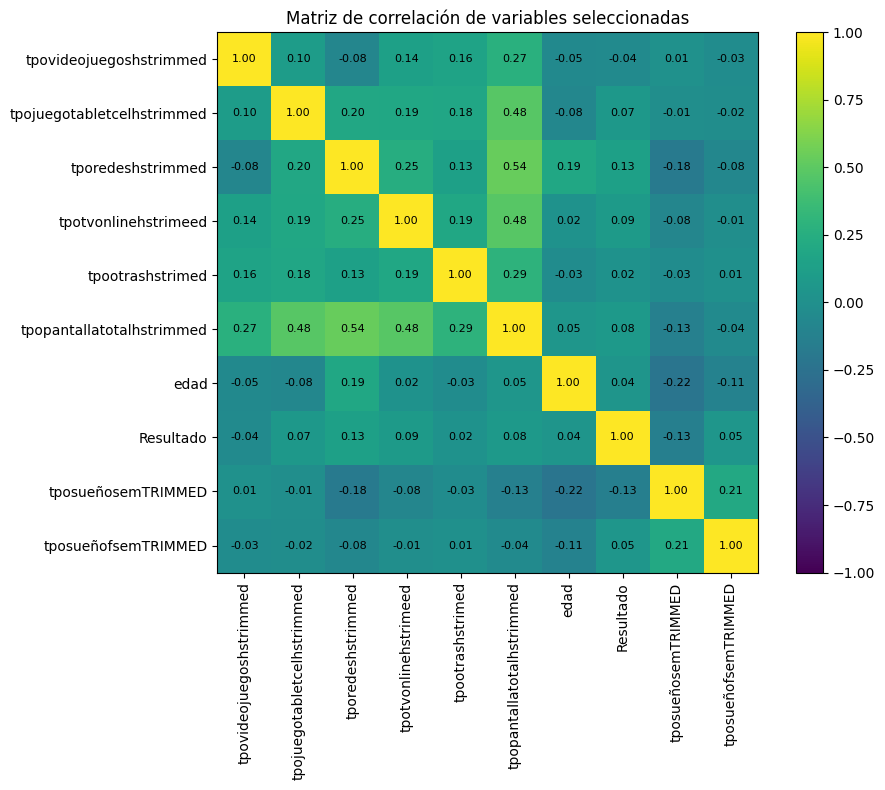

In [98]:
# Nota poner luego de la limpieza de datos.
# Heatmap con matplotlib, limitado a un subconjunto para mantener legibilidad
corr_plot_cols = [
    c for c in [
        "tpovideojuegoshstrimmed",
        "tpojuegotabletcelhstrimmed",
        "tporedeshstrimmed",
        "tpotvonlinehstrimeed",
        "tpootrashstrimed",
        "tpopantallatotalhstrimmed",
        "edad",
        "Resultado",
        "tposueñosemTRIMMED",
        "tposueñofsemTRIMMED",
    ] if c in df.columns
]

if len(corr_plot_cols) >= 2:
    matriz = df[corr_plot_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matriz, vmin=-1, vmax=1)

    ax.set_xticks(range(len(matriz.columns)))
    ax.set_xticklabels(matriz.columns, rotation=90)
    ax.set_yticks(range(len(matriz.columns)))
    ax.set_yticklabels(matriz.columns)

    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            ax.text(j, i, f"{matriz.iloc[i, j]:.2f}",
                    ha="center", va="center", fontsize=8)

    ax.set_title("Matriz de correlación de variables seleccionadas")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

##10 Agrupación conceptual de variables para limpieza de df

Para evitar mezclar funciones, se organizan las variables en grupos conceptuales.

In [116]:
variables_identificacion = [
    c for c in [
        "Submission ID", "Código"
    ] if c in df.columns
]

variables_intensidad = [
    c for c in [
        "tpovideojuegoshstrimmed",
        "tpojuegotabletcelhstrimmed",
        "tporedeshstrimmed",
        "tpotvonlinehstrimeed",
        "tpootrashstrimed",
    ] if c in df.columns
]

variables_dispositivos = [
    c for c in [
        "cantdiascompustrimmed",
        "cantdiascelulartrimmed",
        "cantdiastablettrimmed",
        "cantdiasconsolajuegostrimmed",
        "cantdiastvtrimmed",
    ] if c in df.columns
]

variables_contexto = [
    c for c in [
        "WATCHTVbedtime7D01",
        "COMPUbedtime1D01",
        "COMPUbedtime2D01",
    ] if c in df.columns
]

variables_caracterizacion_demografica = [
    c for c in ["edad", "Sexo", "sexonum", "grado", "Colegio", "Ciudad"]
    if c in df.columns
]

variables_caracterizacion_sueno = [
    c for c in [
        "tposueñosemTRIMMED",
        "tposueñofsemTRIMMED",
        "dursiestasemanahs",
        "difonsetsueño",
        "¿Cuánto tiempo en Minutos tardas en dormirte?",
    ] if c in df.columns
]

variables_caracterizacion_somnolencia = [
    c for c in ["Resultado", "somno01pdss"]
    if c in df.columns
]

variables_caracterizacion_academica = [
    c for c in ["lengua", "matematica", "prom", "aplazos"]
    if c in df.columns
]

grupos_variables = {
    "identificacion": variables_identificacion,
    "cluster_intensidad": variables_intensidad,
    "cluster_dispositivos": variables_dispositivos,
    "cluster_contexto": variables_contexto,
    "caracterizacion_demografica": variables_caracterizacion_demografica,
    "caracterizacion_sueno": variables_caracterizacion_sueno,
    "caracterizacion_somnolencia": variables_caracterizacion_somnolencia,
    "caracterizacion_academica": variables_caracterizacion_academica,
}

for nombre, lista in grupos_variables.items():
    print(f"\n{nombre}: {len(lista)} variables")
    for c in lista:
        print(" -", c)


identificacion: 2 variables
 - Submission ID
 - Código

cluster_intensidad: 5 variables
 - tpovideojuegoshstrimmed
 - tpojuegotabletcelhstrimmed
 - tporedeshstrimmed
 - tpotvonlinehstrimeed
 - tpootrashstrimed

cluster_dispositivos: 5 variables
 - cantdiascompustrimmed
 - cantdiascelulartrimmed
 - cantdiastablettrimmed
 - cantdiasconsolajuegostrimmed
 - cantdiastvtrimmed

cluster_contexto: 3 variables
 - WATCHTVbedtime7D01
 - COMPUbedtime1D01
 - COMPUbedtime2D01

caracterizacion_demografica: 6 variables
 - edad
 - Sexo
 - sexonum
 - grado
 - Colegio
 - Ciudad

caracterizacion_sueno: 5 variables
 - tposueñosemTRIMMED
 - tposueñofsemTRIMMED
 - dursiestasemanahs
 - difonsetsueño
 - ¿Cuánto tiempo en Minutos tardas en dormirte?

caracterizacion_somnolencia: 2 variables
 - Resultado
 - somno01pdss

caracterizacion_academica: 4 variables
 - lengua
 - matematica
 - prom
 - aplazos


# 12. Limpieza y preprocesamiento

In [120]:
# Eliminar columnas con alto % de datos nulos
df_limpio=df.copy()
df_limpio=df_limpio[variables_identificacion +
                         variables_intensidad +
                         variables_dispositivos +
                         variables_contexto +
                         variables_caracterizacion_demografica +
                         variables_caracterizacion_sueno +
                         variables_caracterizacion_somnolencia +
                         variables_caracterizacion_academica]

In [121]:
print("Cant. Variables df_limpio",df_limpio.shape[1])

Cant. Variables df_limpio 32


In [122]:
df_limpio.columns

Index(['Submission ID', 'Código', 'tpovideojuegoshstrimmed',
       'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed',
       'tpotvonlinehstrimeed', 'tpootrashstrimed', 'cantdiascompustrimmed',
       'cantdiascelulartrimmed', 'cantdiastablettrimmed',
       'cantdiasconsolajuegostrimmed', 'cantdiastvtrimmed',
       'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01', 'edad',
       'Sexo', 'sexonum', 'grado', 'Colegio', 'Ciudad', 'tposueñosemTRIMMED',
       'tposueñofsemTRIMMED', 'dursiestasemanahs', 'difonsetsueño',
       '¿Cuánto tiempo en Minutos tardas en dormirte?', 'Resultado',
       'somno01pdss', 'lengua', 'matematica', 'prom', 'aplazos'],
      dtype='object')

In [123]:
# Filtramos entre rangos de edad 12 a 18 años
# Mantendremos únicamente adolescentes con edad dentro del rango documentado

if "edad" in df_limpio.columns:
    fuera_rango = df_limpio["edad"].notna() & ~df_limpio["edad"].between(12, 18, inclusive="both")
    n_fuera = int(fuera_rango.sum())

    df_limpio = df_limpio.loc[~fuera_rango].copy()
else:
  print('NO')
print("Dimensiones luego de aplicar rango etario documentado:", df_limpio.shape)

Dimensiones luego de aplicar rango etario documentado: (4062, 32)


## Variables eliminadas del df_original:
WAZ
* Nulos: 4088
* % de Nulos: 99.34386

Variables calculadas
prom

Variables de Porcentajes (Se pueden inferir con otras variables)
* tpotvonlinePORC
* tpotabletPORC
* tporedesPORC
* tpovideojuegosPORC
* tpootrasPORC

Variables no trimmed y totales(ya que las variantes trimmed presentan mejor calidad)
* tpovideojuegoshs
* tpojuegotabletcelhs
* tporedeshs
* tpotvonlinehs
* tpootrashs
* tpopantallatotalhs
* tpopantallatotalhstrimmed

* cantdiascompus01
* cantdiascelular01
* cantdiastablet01
* cantdiasconsolajuegos01
* cantdiastv01

* tposueñosem
* tpofsueñosem

# 13. Descripción del dataset luego de la limpieza

In [128]:
n_original = len(df_original)
n_limpio = len(df_limpio)
n_vars_original = df_original.shape[1]
n_vars_limpio = df_limpio.shape[1]

display(Markdown(f'''
### Dataset resultante

- Registros originales: **{n_original:,}**
- Registros luego del filtro poblacional: **{n_limpio:,}**
- Variables originales: **{n_vars_original}**
- Variables conservadas en `df_limpio`: **{n_vars_limpio}**

Las variables de sueño, somnolencia, rendimiento académico y demografía se mantienen separadas para la **caracterización posterior de los clusters**. Esto evita que esas características definan artificialmente los grupos de consumo digital.
'''))


### Dataset resultante

- Registros originales: **4,115**
- Registros luego del filtro poblacional: **4,062**
- Variables originales: **125**
- Variables conservadas en `df_limpio`: **32**

Las variables de sueño, somnolencia, rendimiento académico y demografía se mantienen separadas para la **caracterización posterior de los clusters**. Esto evita que esas características definan artificialmente los grupos de consumo digital.


# 14. Exportación del dataset limpio

In [ ]:
# Exportaciones
df_limpio.to_csv("dataset_limpio.csv", index=False)
df_limpio.to_excel("dataset_limpio.xlsx", index=False)

#  Configuraciones experimentales propuestas

Se proponen diferentes vistas del comportamiento digital para estudiar si los clusters se mantienen bajo distintas representaciones.

### Experimento A — Intensidad
Horas de uso por tipo de actividad digital.

### Experimento B — Composición
Proporción del tiempo total dedicada a cada actividad.

### Experimento C — Intensidad + dispositivos
Horas de actividad combinadas con frecuencia de uso de dispositivos.

### Experimento D — Comportamiento digital ampliado
Intensidad + dispositivos + contexto de uso antes de dormir.

Estas configuraciones permiten evaluar si la estructura de grupos depende principalmente de cuánto se utilizan las pantallas, de cómo se distribuye ese uso o del ecosistema de dispositivos y contexto.

In [129]:
experimentos = {
    "A_intensidad": variables_intensidad,
    "B_composicion": variables_intensidad + variables_dispositivos,
    "C_digital_ampliado":
        variables_intensidad
        + variables_dispositivos
        + variables_contexto,
}

for nombre, cols in experimentos.items():
    print(nombre)
    print("  Variables:", len(cols))
    print(" ", cols)
    if cols:
        casos_completos = df[cols].dropna().shape[0]
        print(f"  Casos completos: {casos_completos} ({casos_completos/len(df)*100:.2f}%)")

A_intensidad
  Variables: 5
  ['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed', 'tpotvonlinehstrimeed', 'tpootrashstrimed']
  Casos completos: 3744 (90.98%)
B_composicion
  Variables: 10
  ['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed', 'tpotvonlinehstrimeed', 'tpootrashstrimed', 'cantdiascompustrimmed', 'cantdiascelulartrimmed', 'cantdiastablettrimmed', 'cantdiasconsolajuegostrimmed', 'cantdiastvtrimmed']
  Casos completos: 3562 (86.56%)
C_digital_ampliado
  Variables: 13
  ['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed', 'tpotvonlinehstrimeed', 'tpootrashstrimed', 'cantdiascompustrimmed', 'cantdiascelulartrimmed', 'cantdiastablettrimmed', 'cantdiasconsolajuegostrimmed', 'cantdiastvtrimmed', 'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01']
  Casos completos: 3562 (86.56%)


## Estrategia adoptada
En una primer instancia, decidimos ir por el experimento "A" para el modelo de clustering. Donde utilizaremos como **baseline** donde usaremos las versiones tratadas (`trimmed`) porque:

1. representan directamente la cantidad de tiempo destinada a diferentes actividades;
2. permiten formar perfiles interpretables;
3. evitan introducir simultáneamente la variable original, categorizada y binaria de una misma característica;
4. el dataset ya contiene versiones tratadas que permiten comparar la lógica de depuración con los valores originales.

La decisión final seguirá siendo auditable: se conservará `df_original`, y se documentará cuántos registros se pierden por cada criterio.

Para este primer dataset limpio no se eliminarán registros únicamente por carecer de variables de caracterización.

In [130]:
# Dataset de clustering baseline: Experimento A
cols_cluster = variables_intensidad.copy()

if not cols_cluster:
    raise ValueError("No se encontraron las variables de intensidad esperadas.")

# Identificador para trazabilidad
id_principal = "Submission ID" if "Submission ID" in df_limpio.columns else None

cols_base = ([id_principal] if id_principal else []) + cols_cluster

df_cluster = df_limpio[cols_base].copy()

# Casos incompletos para variables esenciales de clustering
mask_incompletos = df_cluster[cols_cluster].isna().any(axis=1)
n_incompletos = int(mask_incompletos.sum())

df_cluster = df_cluster.loc[~mask_incompletos].copy()

print("Dataset de clustering baseline:", df_cluster.shape)
display(df_cluster.head())

Dataset de clustering baseline: (3703, 6)


,Submission ID,tpovideojuegoshstrimmed,tpojuegotabletcelhstrimmed,tporedeshstrimmed,tpotvonlinehstrimeed,tpootrashstrimed
0,4363218715845085057,0.0,5.000000,4.000000,1.000000,1.000000
1,4363225955846355489,3.0,6.000000,1.000000,0.500000,0.000000
2,4363219855845435174,6.0,2.000000,4.000000,1.000000,0.000000
4,4363224915847071805,0.0,8.166667,10.333333,9.833333,5.666667
5,4363222435841124053,0.0,4.000000,3.000000,3.000000,1.000000


In [131]:
# Dataset de caracterización con el mismo universo de participantes del clustering
vars_caracterizacion = list(dict.fromkeys(
    variables_caracterizacion_demografica
    + variables_caracterizacion_sueno
    + variables_caracterizacion_somnolencia
    + variables_caracterizacion_academica
))

if id_principal:
    ids_cluster = set(df_cluster[id_principal])
    df_caracterizacion = df_limpio[
        df_limpio[id_principal].isin(ids_cluster)
    ][[id_principal] + vars_caracterizacion].copy()
else:
    df_caracterizacion = df_limpio.loc[
        df_cluster.index, vars_caracterizacion
    ].copy()

print("Dataset de caracterización:", df_caracterizacion.shape)
display(df_caracterizacion.head())

Dataset de caracterización: (3703, 18)


,Submission ID,edad,Sexo,sexonum,grado,Colegio,Ciudad,tposueñosemTRIMMED,tposueñofsemTRIMMED,dursiestasemanahs,difonsetsueño,¿Cuánto tiempo en Minutos tardas en dormirte?,Resultado,somno01pdss,lengua,matematica,prom,aplazos
0,4363218715845085057,NaN,Femenino,0,1,1,1,6.666667,12.666666,3.000000,0.333333,20.0,21,1,NaN,NaN,NaN,NaN
1,4363225955846355489,12.0,Masculino,1,1,1,1,7.166667,10.500000,0.000000,3.000000,30.0,21,1,NaN,NaN,NaN,NaN
2,4363219855845435174,13.0,Masculino,1,1,1,1,6.000000,6.000000,3.000000,4.500000,20.0,30,1,NaN,NaN,NaN,NaN
4,4363224915847071805,NaN,Masculino,1,1,1,1,NaN,4.833333,3.166667,15.166667,30.0,19,1,NaN,NaN,NaN,NaN
5,4363222435841124053,NaN,Masculino,1,1,1,1,7.166667,10.000000,6.000000,0.500000,20.0,5,0,NaN,NaN,NaN,NaN


# 15. Preparación de variables para clustering

Los algoritmos basados en distancia, como K-Means, son sensibles a la escala. Una variable con una magnitud numérica mayor puede dominar artificialmente la distancia entre observaciones.

Por ese motivo se estandarizarán las variables antes del modelado.

In [132]:
X_cluster = df_cluster[cols_cluster].copy()

# Verificación final
print("Missing por variable:")
display(X_cluster.isna().sum().rename("missing").to_frame())

print("\nEstadísticos antes del escalado:")
display(X_cluster.describe().T)

Missing por variable:


,missing
tpovideojuegoshstrimmed,0
tpojuegotabletcelhstrimmed,0
tporedeshstrimmed,0
tpotvonlinehstrimeed,0
tpootrashstrimed,0



Estadísticos antes del escalado:


,count,mean,std,min,25%,50%,75%,max
tpovideojuegoshstrimmed,3703.0,0.960843,1.749812,0.0,0.000000,0.000000,1.083333,12.000000
tpojuegotabletcelhstrimmed,3703.0,1.801737,2.240006,0.0,0.166667,1.000000,2.500000,12.500000
tporedeshstrimmed,3703.0,3.066748,2.553690,0.0,1.000000,2.333333,4.000000,12.833333
tpotvonlinehstrimeed,3703.0,2.381357,1.962632,0.0,1.000000,2.000000,3.000000,12.500000
tpootrashstrimed,3703.0,0.822081,1.628712,0.0,0.000000,0.000000,1.000000,12.000000


In [57]:
# StandardScaler como baseline
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_cluster)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_cluster.columns,
    index=X_cluster.index
)

print("Media aproximada luego del escalado:")
display(X_scaled.mean().round(6).to_frame("media"))

print("Desvío estándar aproximado:")
display(X_scaled.std(ddof=0).round(6).to_frame("std"))

Media aproximada luego del escalado:


,media
tpovideojuegoshstrimmed,-0.0
tpojuegotabletcelhstrimmed,0.0
tporedeshstrimmed,-0.0
tpotvonlinehstrimeed,0.0
tpootrashstrimed,0.0


Desvío estándar aproximado:


,std
tpovideojuegoshstrimmed,1.0
tpojuegotabletcelhstrimmed,1.0
tporedeshstrimmed,1.0
tpotvonlinehstrimeed,1.0
tpootrashstrimed,1.0


### StandardScaler vs RobustScaler

Se utilizará **StandardScaler** como opción inicial porque K-Means optimiza distancias euclidianas y el dataset ya contiene versiones tratadas de las variables de consumo.

Como análisis de sensibilidad puede utilizarse **RobustScaler**, especialmente si luego se decide conservar valores extremos válidos. RobustScaler utiliza mediana y rango intercuartílico, por lo que es menos sensible a extremos.

In [58]:
# Alternativa opcional
robust_scaler = RobustScaler()
X_robust = pd.DataFrame(
    robust_scaler.fit_transform(X_cluster),
    columns=X_cluster.columns,
    index=X_cluster.index
)

display(X_robust.head())

,tpovideojuegoshstrimmed,tpojuegotabletcelhstrimmed,tporedeshstrimmed,tpotvonlinehstrimeed,tpootrashstrimed
0,0.000000,1.714286,0.555556,-0.500000,1.000000
1,2.769231,2.142857,-0.444444,-0.750000,0.000000
2,5.538461,0.428571,0.555556,-0.500000,0.000000
4,0.000000,3.071428,2.666667,3.916667,5.666666
5,0.000000,1.285714,0.222222,0.500000,1.000000


# 16. Modelo de Aprendizaje Automático propuesto

El problema es de **aprendizaje automático no supervisado** porque no existe una etiqueta objetivo conocida que indique de antemano a qué perfil pertenece cada adolescente.

El objetivo es descubrir agrupamientos naturales a partir de similitudes en sus patrones de consumo digital.

## Modelo inicial: K-Means

K-Means se propone como modelo baseline porque:

- es un algoritmo clásico de segmentación;
- funciona eficientemente con datasets de este tamaño;
- permite trabajar con variables numéricas estandarizadas;
- produce clusters relativamente fáciles de interpretar;
- permite comparar diferentes valores de `K`;
- facilita la posterior caracterización de cada grupo.

### Limitaciones

K-Means supone implícitamente grupos relativamente compactos en términos de distancia euclidiana y es sensible a:

- la escala de las variables;
- los valores extremos;
- la elección de K;
- la presencia de estructuras no esféricas.

Por esta razón, no se asumirá que K-Means es necesariamente el mejor modelo.

### Alternativas

- **Clustering jerárquico:** útil para estudiar relaciones jerárquicas entre observaciones o grupos.
- **DBSCAN:** útil cuando existen clusters de formas irregulares y ruido, aunque puede ser sensible a sus hiperparámetros.
- **Gaussian Mixture Models:** permite una asignación probabilística a clusters y mayor flexibilidad en la geometría de los grupos.

# 17. Selección exploratoria del número de clusters

In [60]:
RANDOM_STATE = 42

In [61]:
metricas_k = []

for k in range(2, 11):
    modelo = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = modelo.fit_predict(X_scaled)

    metricas_k.append({
        "k": k,
        "inertia": modelo.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
    })

metricas_k_df = pd.DataFrame(metricas_k)
display(metricas_k_df)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,14668.288705,0.369383,970.575286,1.773307
1,3,12478.908493,0.354164,894.852294,1.553154
2,4,10734.023962,0.327286,893.788153,1.403471
3,5,9362.447941,0.314981,903.774715,1.253878
4,6,8552.749538,0.302569,861.259366,1.194031
5,7,7996.709037,0.230291,810.247335,1.250378
6,8,7499.282596,0.232582,775.370849,1.246931
7,9,7082.414875,0.233716,745.366697,1.227752
8,10,6652.447774,0.239751,731.701211,1.242519


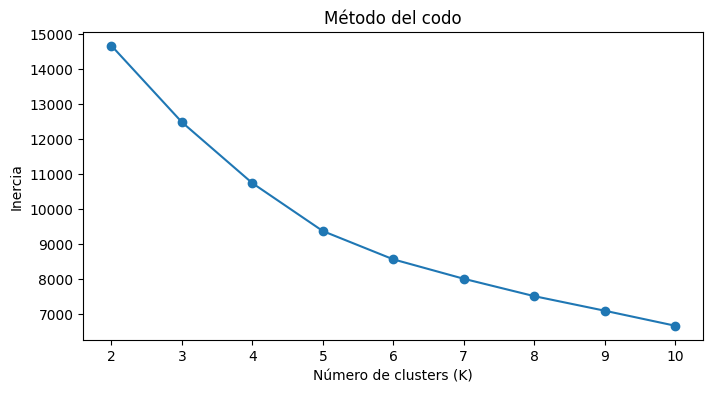

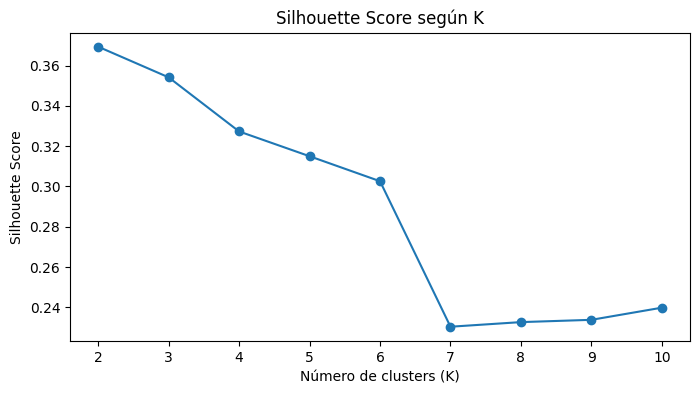

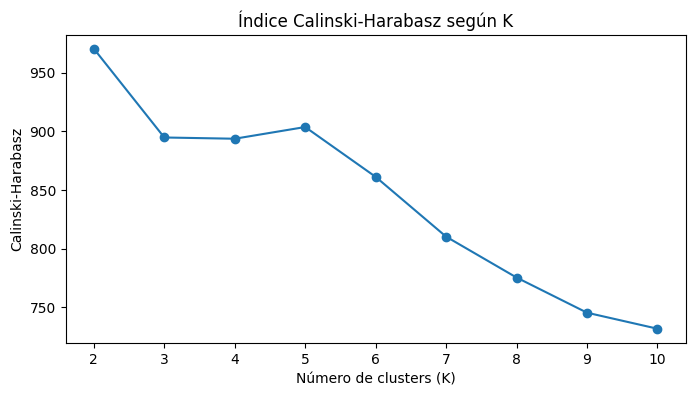

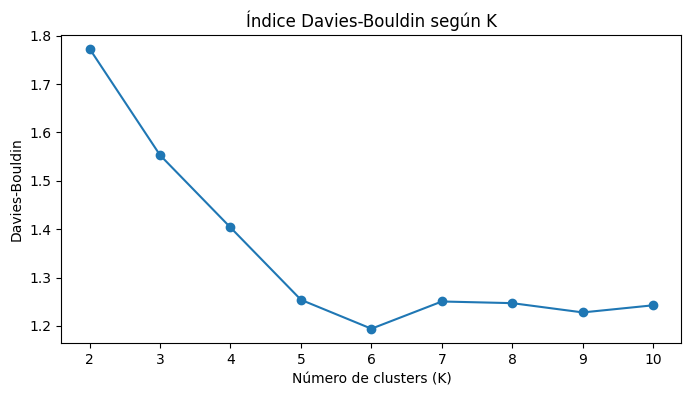

In [62]:
# Método del codo
plt.figure(figsize=(8, 4))
plt.plot(metricas_k_df["k"], metricas_k_df["inertia"], marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(metricas_k_df["k"])
plt.show()

# Silhouette
plt.figure(figsize=(8, 4))
plt.plot(metricas_k_df["k"], metricas_k_df["silhouette"], marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score según K")
plt.xticks(metricas_k_df["k"])
plt.show()

# Calinski-Harabasz
plt.figure(figsize=(8, 4))
plt.plot(metricas_k_df["k"], metricas_k_df["calinski_harabasz"], marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz según K")
plt.xticks(metricas_k_df["k"])
plt.show()

# Davies-Bouldin
plt.figure(figsize=(8, 4))
plt.plot(metricas_k_df["k"], metricas_k_df["davies_bouldin"], marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin según K")
plt.xticks(metricas_k_df["k"])
plt.show()

In [63]:
mejor_sil = metricas_k_df.loc[metricas_k_df["silhouette"].idxmax()]
mejor_ch = metricas_k_df.loc[metricas_k_df["calinski_harabasz"].idxmax()]
mejor_db = metricas_k_df.loc[metricas_k_df["davies_bouldin"].idxmin()]

display(Markdown(f'''
### Lectura inicial de las métricas

- Mejor Silhouette Score: **K = {int(mejor_sil["k"])}**, valor = **{mejor_sil["silhouette"]:.3f}**
- Mejor Calinski-Harabasz: **K = {int(mejor_ch["k"])}**
- Mejor Davies-Bouldin: **K = {int(mejor_db["k"])}**, valor = **{mejor_db["davies_bouldin"]:.3f}**

Estas métricas no deben utilizarse aisladamente. La cantidad final de clusters debe decidirse considerando también la estabilidad de los grupos, su separación y, especialmente, su **interpretabilidad sustantiva**.
'''))


### Lectura inicial de las métricas

- Mejor Silhouette Score: **K = 2**, valor = **0.369**
- Mejor Calinski-Harabasz: **K = 2**
- Mejor Davies-Bouldin: **K = 6**, valor = **1.194**

Estas métricas no deben utilizarse aisladamente. La cantidad final de clusters debe decidirse considerando también la estabilidad de los grupos, su separación y, especialmente, su **interpretabilidad sustantiva**.


# 18. PCA para visualización exploratoria

PCA no reemplaza las variables originales. Aquí se utiliza principalmente como herramienta para comprender cuánta variabilidad puede representarse en pocas dimensiones y para facilitar una futura visualización 2D de los clusters.

,componente,varianza_explicada,varianza_acumulada
0,1,0.321580,0.321580
1,2,0.218455,0.540035
2,3,0.165537,0.705571
3,4,0.160320,0.865892
4,5,0.134108,1.000000


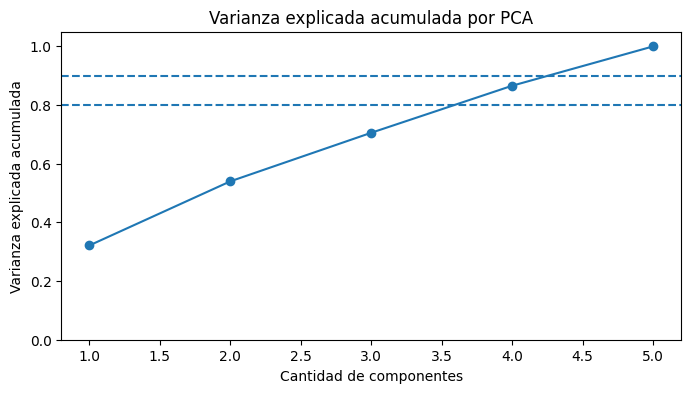

In [64]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

pca_resumen = pd.DataFrame({
    "componente": np.arange(1, len(varianza) + 1),
    "varianza_explicada": varianza,
    "varianza_acumulada": varianza_acum,
})

display(pca_resumen)

plt.figure(figsize=(8, 4))
plt.plot(
    pca_resumen["componente"],
    pca_resumen["varianza_acumulada"],
    marker="o"
)
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Cantidad de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.ylim(0, 1.05)
plt.show()

# 19. Modelado exploratorio opcional

La siguiente sección permite entrenar un modelo K-Means con un valor de K elegido manualmente y comenzar a caracterizar los clusters.

**Importante:** este bloque debe considerarse parte del modelado exploratorio, separado del EDA y la limpieza.

In [65]:
# Elegir K manualmente luego de revisar las métricas.
K_ELEGIDO = 3

modelo_final_exploratorio = KMeans(
    n_clusters=K_ELEGIDO,
    random_state=RANDOM_STATE,
    n_init=20
)

labels = modelo_final_exploratorio.fit_predict(X_scaled)

df_cluster_modelado = df_cluster.copy()
df_cluster_modelado["cluster"] = labels

print("Cantidad de participantes por cluster:")
display(
    df_cluster_modelado["cluster"]
    .value_counts()
    .sort_index()
    .rename("cantidad")
    .to_frame()
)

Cantidad de participantes por cluster:


,cantidad
cluster,
0,2504
1,785
2,414


In [66]:
# Perfil medio de las variables que FORMARON los clusters
perfil_clusters = (
    df_cluster_modelado
    .groupby("cluster")[cols_cluster]
    .mean()
    .round(2)
)

display(perfil_clusters)

,tpovideojuegoshstrimmed,tpojuegotabletcelhstrimmed,tporedeshstrimmed,tpotvonlinehstrimeed,tpootrashstrimed
cluster,,,,,
0,0.44,1.08,2.26,1.74,0.44
1,0.51,3.87,6.06,4.03,1.66
2,4.94,2.22,2.28,3.13,1.56


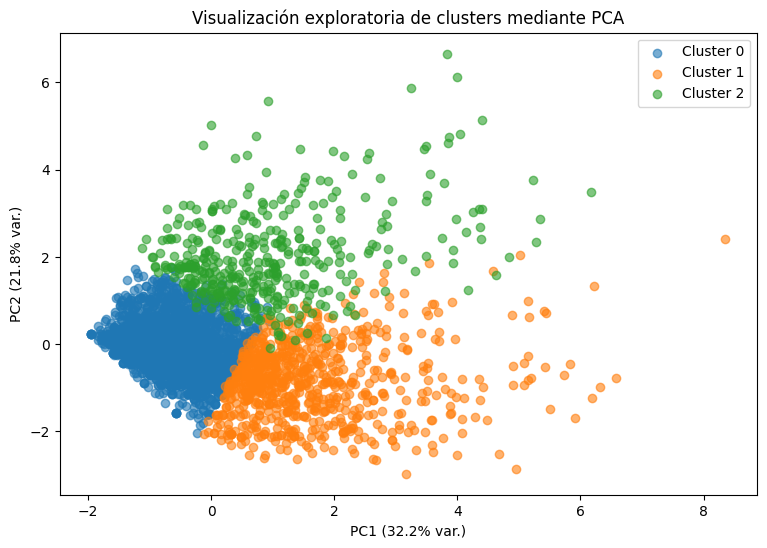

In [67]:
# Visualización 2D con PCA
pca_2 = PCA(n_components=2)
coords = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "cluster": labels
}, index=X_scaled.index)

plt.figure(figsize=(9, 6))

for cl in sorted(df_pca["cluster"].unique()):
    subset = df_pca[df_pca["cluster"] == cl]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Cluster {cl}"
    )

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("Visualización exploratoria de clusters mediante PCA")
plt.legend()
plt.show()

## 19.1 Caracterización posterior de clusters

La caracterización utiliza variables externas al proceso de formación de clusters. Esto permite responder preguntas como:

- ¿Qué edad promedio tiene cada perfil?
- ¿Cómo se distribuye el sexo?
- ¿Existen diferencias descriptivas en sueño?
- ¿Cómo se distribuye el puntaje de somnolencia?
- ¿Qué ocurre con el rendimiento académico cuando la información está disponible?

Estas comparaciones son descriptivas y no implican causalidad.

In [ ]:
if id_principal and id_principal in df_caracterizacion.columns:
    df_resultados = df_cluster_modelado.merge(
        df_caracterizacion,
        on=id_principal,
        how="left"
    )
else:
    df_resultados = df_cluster_modelado.join(df_caracterizacion, how="left")

# Resumen numérico por cluster
vars_num_caract = [
    c for c in [
        "edad",
        "grado",
        "tposueñosemTRIMMED",
        "tposueñofsemTRIMMED",
        "Resultado",
        "prom",
    ] if c in df_resultados.columns
]

if vars_num_caract:
    print("Promedios de caracterización:")
    display(
        df_resultados
        .groupby("cluster")[vars_num_caract]
        .mean()
        .round(2)
    )

if "Sexo" in df_resultados.columns:
    print("\nDistribución porcentual de Sexo por cluster:")
    tabla_sexo = pd.crosstab(
        df_resultados["cluster"],
        df_resultados["Sexo"],
        normalize="index"
    ) * 100
    display(tabla_sexo.round(1))

# 20. Conclusiones del Análisis Exploratorio

La siguiente celda genera automáticamente una síntesis basada en los datos efectivamente procesados.

In [ ]:
n_missing_cluster_pre = int(
    df_limpio[variables_cluster_intensidad].isna().any(axis=1).sum()
) if variables_cluster_intensidad else 0

texto_conclusion = f'''
## Síntesis del EDA

El dataset original contiene **{df_original.shape[0]:,} registros** y **{df_original.shape[1]} variables**.

Luego de aplicar el criterio poblacional documentado, el dataset principal contiene **{df_limpio.shape[0]:,} registros**. Para el experimento baseline de clustering por intensidad se dispone de **{df_cluster.shape[0]:,} casos completos** y **{len(cols_cluster)} variables** de comportamiento digital.

Se evitó utilizar identificadores y variables administrativas para formar clusters. También se separaron las variables de sueño, somnolencia, rendimiento académico y demografía, reservándolas principalmente para la caracterización posterior de los perfiles.

Antes del clustering se revisaron:

- valores faltantes;
- registros duplicados;
- indicadores de completitud y exclusión;
- valores extremos;
- consistencia del tiempo total de pantalla;
- composición porcentual del consumo;
- redundancia entre variables originales, tratadas, categorizadas y binarias.

El enfoque principal propuesto es **K-Means** sobre variables estandarizadas de intensidad de consumo digital, acompañado por experimentos alternativos de composición, dispositivos y contexto de uso.

La elección final del número de clusters no debe depender de una única métrica, sino de la combinación de Silhouette Score, Calinski-Harabasz, Davies-Bouldin, análisis del codo, estabilidad e interpretabilidad de los perfiles.

Finalmente, las asociaciones descriptivas entre clusters y variables de sueño, somnolencia, demografía o rendimiento académico no deben interpretarse como evidencia causal.
'''

display(Markdown(texto_conclusion))

# 21. Archivos finales y reproducibilidad

Al finalizar la ejecución completa del notebook deberían quedar disponibles:

- `dataset_limpio.csv`
- `dataset_limpio.xlsx`
- `dataset_cluster.csv`
- `dataset_caracterizacion.csv`
- `acciones_limpieza.csv`

Además, el notebook conserva `df_original` sin modificaciones para garantizar trazabilidad y reproducibilidad.